# Experimentos de desbalanceo en CGM

Este notebook genera escenarios controlados y reproducibles para estudiar desbalanceo en series temporales de glucosa. Se simulan condiciones realistas observadas en el EDA: desbalanceo global de clases, heterogeneidad inter-paciente, fragmentacion temporal, variaciones en volumen de datos y escenarios hibridos. Cada experimento incluye motivacion tecnica, justificacion clinica e hipotesis, y produce datasets listos para el notebook de tecnicas de balanceo.

## Setup y dataset sintetico base

Para asegurar reproducibilidad, partimos de un generador sintetico simple de CGM. El objetivo no es replicar un dataset real con precision, sino crear una base coherente donde se puedan aplicar transformaciones de desbalanceo de forma controlada. Las funciones siguientes crean series por paciente, etiquetan hipoglucemia/normoglucemia/hiperglucemia y generan identificadores de episodios clinicos.

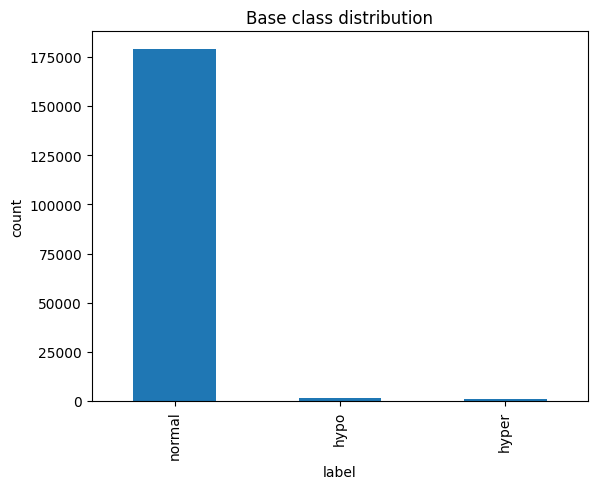

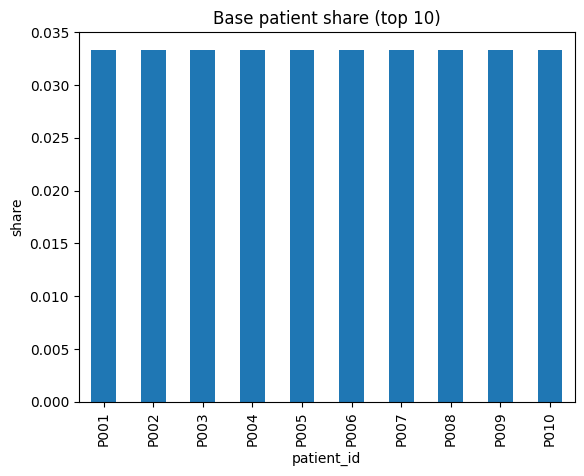

,patient_id,timestamp,time_idx,glucose,label,episode_id
0,P001,2020-01-01 00:00:00,0,113.256764,normal,None
1,P001,2020-01-01 00:05:00,1,131.161117,normal,None
2,P001,2020-01-01 00:10:00,2,133.062252,normal,None
3,P001,2020-01-01 00:15:00,3,104.146253,normal,None
4,P001,2020-01-01 00:20:00,4,110.634810,normal,None


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
rng = np.random.default_rng(SEED)

def clamp_glucose(values):
    return np.clip(values, 39, 401)

def label_glucose(values):
    values = np.asarray(values)
    return np.select(
        [values < 70, values > 180],
        ['hypo', 'hyper'],
        default='normal',
    )

def simulate_patient_series(patient_id, start_ts, days, freq_min, rng_local):
    n_steps = int(days * 24 * 60 / freq_min)
    timestamps = pd.date_range(start_ts, periods=n_steps, freq=f'{freq_min}min')
    base = rng_local.normal(120, 12)
    noise = rng_local.normal(0, 10, size=n_steps)
    series = base + noise

    n_hypo = rng_local.integers(2, 6)
    n_hyper = rng_local.integers(2, 5)
    for _ in range(n_hypo):
        start = rng_local.integers(0, n_steps - 20)
        length = rng_local.integers(6, 24)
        depth = rng_local.integers(40, 90)
        series[start:start + length] -= depth
    for _ in range(n_hyper):
        start = rng_local.integers(0, n_steps - 20)
        length = rng_local.integers(6, 28)
        height = rng_local.integers(50, 100)
        series[start:start + length] += height

    series = clamp_glucose(series)
    df = pd.DataFrame(
        {
            'patient_id': patient_id,
            'timestamp': timestamps,
            'time_idx': np.arange(n_steps),
            'glucose': series,
        }
    )
    return df

def add_episode_id(df):
    df = df.sort_values(['patient_id', 'timestamp']).reset_index(drop=True)
    df['label'] = label_glucose(df['glucose'])
    episode_ids = []
    for patient_id, group in df.groupby('patient_id', sort=False):
        prev_label = None
        ep = 0
        for label in group['label']:
            if label in ('hypo', 'hyper'):
                if label != prev_label:
                    ep += 1
                episode_ids.append(f'{patient_id}_{label}_{ep}')
            else:
                episode_ids.append(None)
            prev_label = label
    df['episode_id'] = episode_ids
    return df

def generate_synthetic_cgm(n_patients=30, days=21, freq_min=5, seed=SEED):
    rng_local = np.random.default_rng(seed)
    start_ts = pd.Timestamp('2020-01-01')
    dfs = []
    for i in range(n_patients):
        patient_id = f'P{str(i + 1).zfill(3)}'
        df_p = simulate_patient_series(patient_id, start_ts, days, freq_min, rng_local)
        dfs.append(df_p)
    df = pd.concat(dfs, ignore_index=True)
    df = add_episode_id(df)
    return df, freq_min

def plot_class_dist(df, title):
    counts = df['label'].value_counts()
    counts.plot(kind='bar')
    plt.title(title)
    plt.ylabel('count')
    plt.show()

def plot_patient_share(df, title, top_n=10):
    shares = df['patient_id'].value_counts(normalize=True).head(top_n)
    shares.plot(kind='bar')
    plt.title(title)
    plt.ylabel('share')
    plt.show()

base_df, FREQ_MIN = generate_synthetic_cgm()
plot_class_dist(base_df, 'Base class distribution')
plot_patient_share(base_df, 'Base patient share (top 10)')
base_df.head()

## Experimento A - Global class imbalance scaling

Este experimento simula niveles crecientes de desbalanceo global entre hipoglucemia y no-hipoglucemia (normal + hiper). La motivacion tecnica es medir como cambia el rendimiento cuando la clase critica es extremadamente rara. Clinicamente, refleja la baja frecuencia real de hipoglucemia en CGM, especialmente en cohortes con buen control o con sensores con cobertura incompleta. La hipotesis es que cuanto mas extrema la rareza, mas inestable es el entrenamiento y mayor el riesgo de ignorar eventos clinicamente peligrosos. Esto se relaciona con DIATREND (ratio muy severo), REPLACE-BG (menos severo) y T1DiabetesGranada (mas equilibrado).

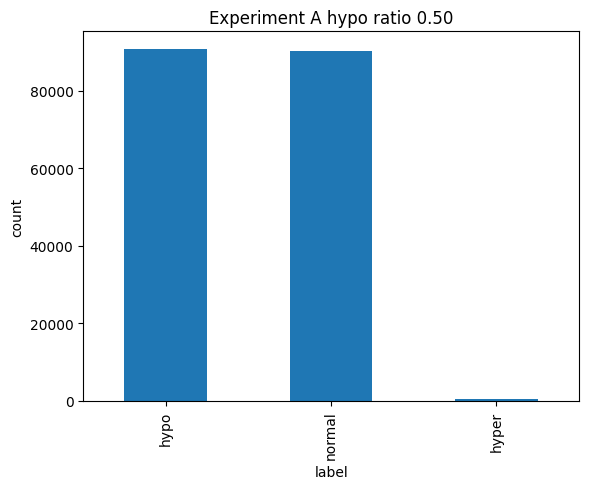

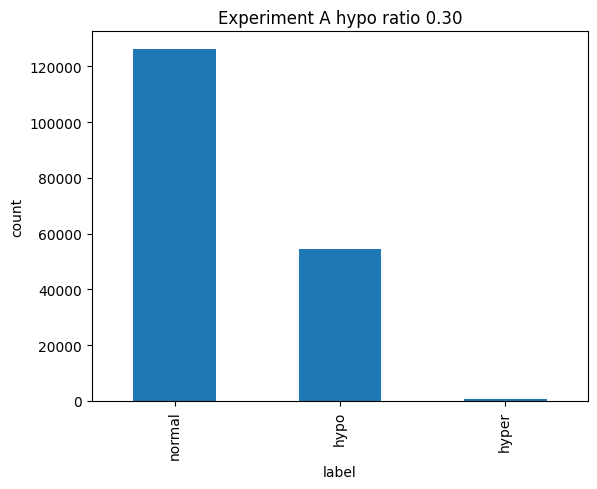

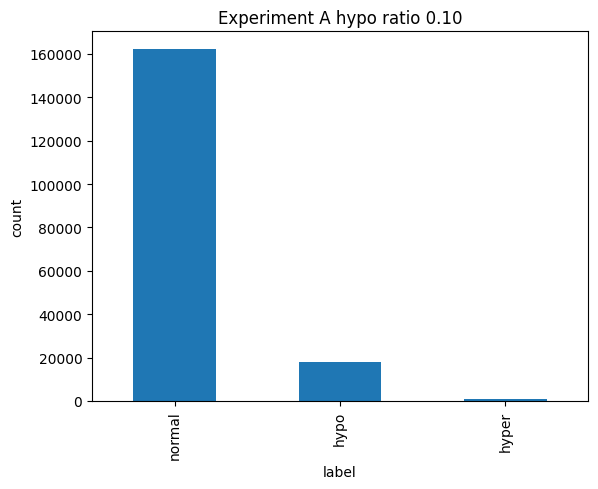

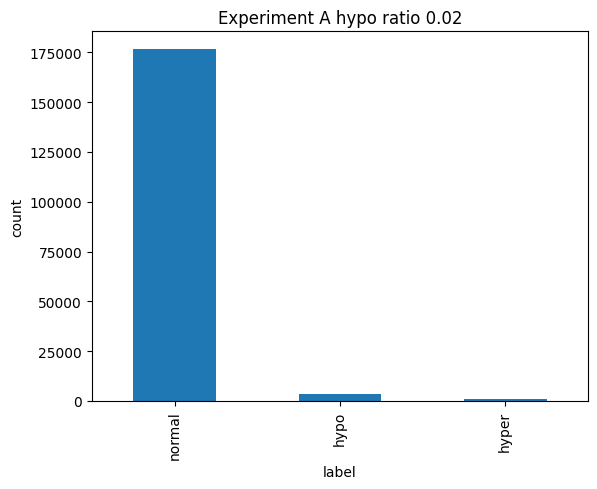

,patient_id,timestamp,time_idx,glucose,label,episode_id
0,P025,2020-01-21 05:45:00,5829,115.974569,normal,None
1,P030,2020-01-07 07:55:00,1823,51.897903,hypo,P030_hypo_5
2,P009,2020-01-15 23:00:00,4308,108.661490,normal,None
3,P003,2020-01-07 19:25:00,1961,39.000000,hypo,P003_hypo_3
4,P028,2020-01-16 00:55:00,4331,145.001068,normal,None


In [2]:
def scale_global_hypo_ratio(df, hypo_ratio, seed=SEED):
    hypo = df[df['label'] == 'hypo']
    non = df[df['label'] != 'hypo']
    total = len(df)
    target_hypo = int(total * hypo_ratio)
    target_non = total - target_hypo
    hypo_sample = hypo.sample(
        target_hypo,
        replace=target_hypo > len(hypo),
        random_state=seed,
    )
    non_sample = non.sample(
        target_non,
        replace=target_non > len(non),
        random_state=seed,
    )
    out = pd.concat([hypo_sample, non_sample], ignore_index=True)
    out = out.sample(frac=1, random_state=seed).reset_index(drop=True)
    return out

ratios = [0.50, 0.30, 0.10, 0.02]
expA = {}
for r in ratios:
    name = f'expA_hypo_{int(r * 100)}'
    expA[name] = scale_global_hypo_ratio(base_df, r)
    plot_class_dist(expA[name], f'Experiment A hypo ratio {r:.2f}')

expA[list(expA.keys())[0]].head()

## Experimento B - Patient-level imbalance

Aqui se modela heterogeneidad inter-paciente: algunos pacientes dominan el dataset (tipo DIATREND), distribucion uniforme (tipo REPLACE-BG) y mezcla extrema (T1DiabetesGranada real). La motivacion tecnica es evaluar sesgos de representacion cuando el modelo ve demasiadas observaciones de pocos sujetos. Clinicamente, esto refleja cohortes donde pocos pacientes aportan anos de CGM y otros tienen registros escasos. La hipotesis es que el modelo aprende patrones idiosincraticos de los pacientes dominantes, reduciendo generalizacion y sensibilidad a hipoglucemia en pacientes con poca representacion.

C:\Users\User\AppData\Local\Temp\ipykernel_8788\3025363988.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), per_patient), random_state=seed))


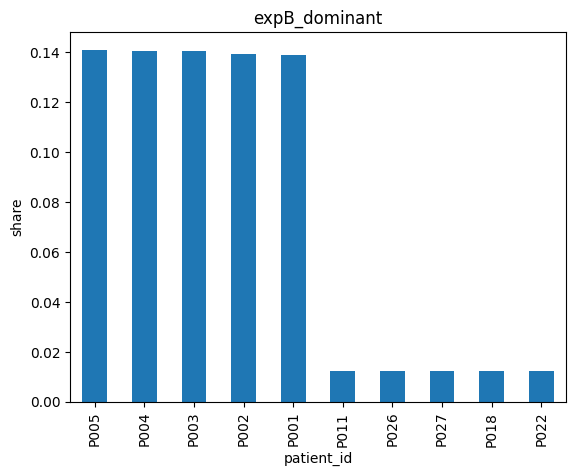

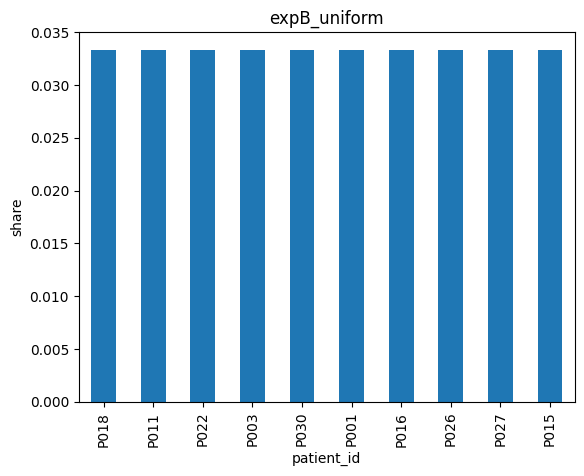

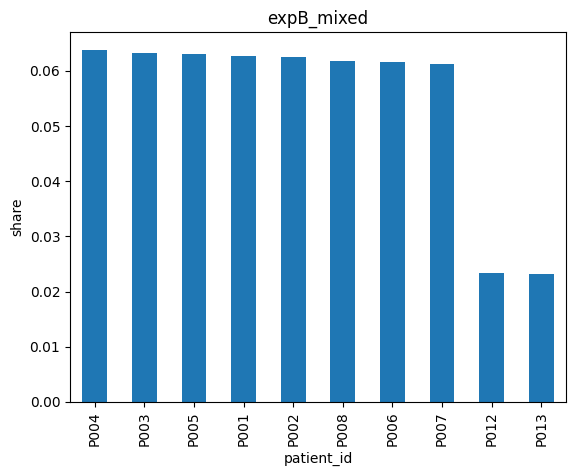

,patient_id,timestamp,time_idx,glucose,label,episode_id
0,P002,2020-01-06 06:30:00,1518,111.630694,normal,None
1,P002,2020-01-09 23:05:00,2581,116.064977,normal,None
2,P010,2020-01-07 09:45:00,1845,105.231396,normal,None
3,P003,2020-01-14 09:45:00,3861,103.761512,normal,None
4,P009,2020-01-12 10:35:00,3295,124.744584,normal,None


In [3]:
def patient_level_imbalance(df, mode, seed=SEED):
    patient_counts = df['patient_id'].value_counts()
    patients = patient_counts.index.to_list()
    if mode == 'dominant':
        top = patients[:5]
        dominant = df[df['patient_id'].isin(top)]
        rest = df[~df['patient_id'].isin(top)]
        dominant_sample = dominant.sample(
            int(len(df) * 0.7),
            replace=True,
            random_state=seed,
        )
        rest_sample = rest.sample(
            len(df) - len(dominant_sample),
            replace=False,
            random_state=seed,
        )
        out = pd.concat([dominant_sample, rest_sample], ignore_index=True)
    elif mode == 'uniform':
        per_patient = int(len(df) / len(patients))
        out = (
            df.groupby('patient_id', group_keys=False)
            .apply(lambda g: g.sample(min(len(g), per_patient), random_state=seed))
        )
        out = out.reset_index(drop=True)
    elif mode == 'mixed':
        top = patients[:8]
        dominant = df[df['patient_id'].isin(top)]
        rest = df[~df['patient_id'].isin(top)]
        dominant_sample = dominant.sample(
            int(len(df) * 0.5),
            replace=True,
            random_state=seed,
        )
        rest_sample = rest.sample(
            len(df) - len(dominant_sample),
            replace=True,
            random_state=seed,
        )
        out = pd.concat([dominant_sample, rest_sample], ignore_index=True)
    else:
        raise ValueError('mode must be dominant, uniform, or mixed')
    out = out.sample(frac=1, random_state=seed).reset_index(drop=True)
    return out

expB = {
    'expB_dominant': patient_level_imbalance(base_df, 'dominant'),
    'expB_uniform': patient_level_imbalance(base_df, 'uniform'),
    'expB_mixed': patient_level_imbalance(base_df, 'mixed'),
}
for name, df in expB.items():
    plot_patient_share(df, name)

expB['expB_dominant'].head()

## Experimento C - Temporal fragmentation

Este bloque reproduce la fragmentacion temporal observada en T1DiabetesGranada. Tecnica y clinicamente, los gaps reflejan fallos de sensores, interrupciones de uso o perdida de sincronizacion. La hipotesis es que la fragmentacion reduce la capacidad de aprender dinamica de episodios completos y distorsiona el contexto previo a eventos criticos. Se simulan series completas, series con gaps, ventanas cortas (1-3 dias) y ventanas largas (14-30 dias).

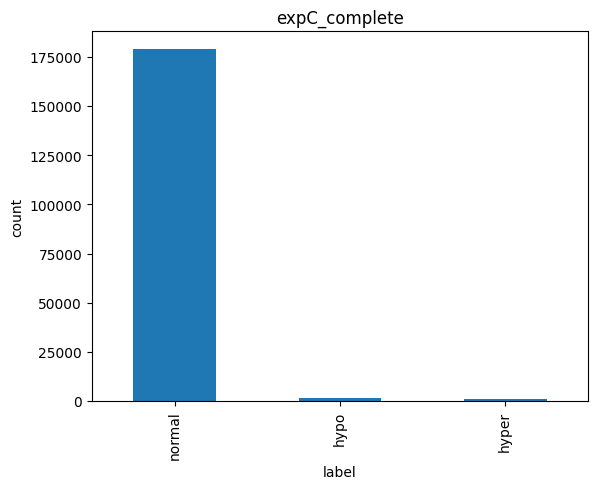

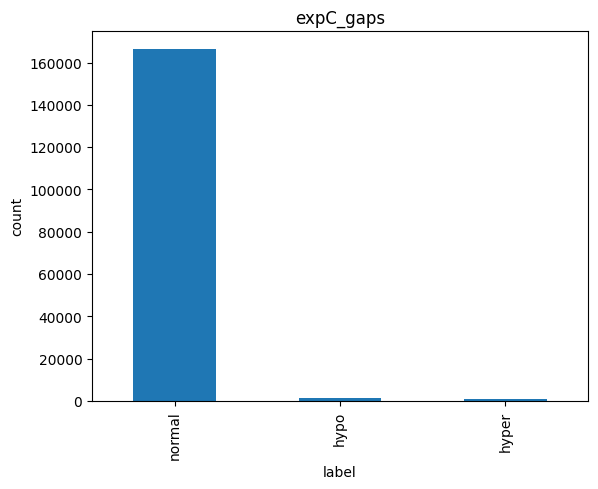

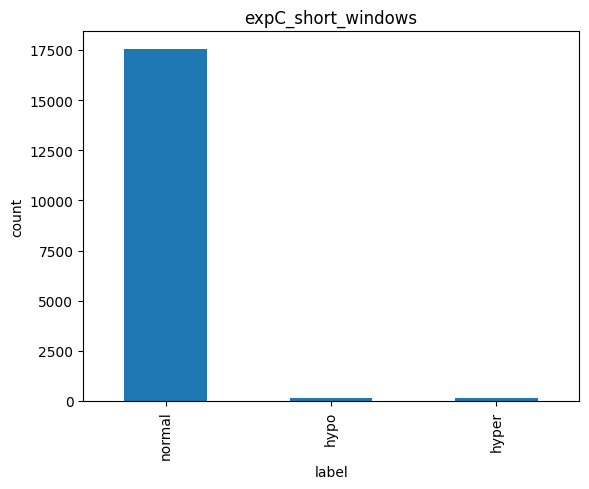

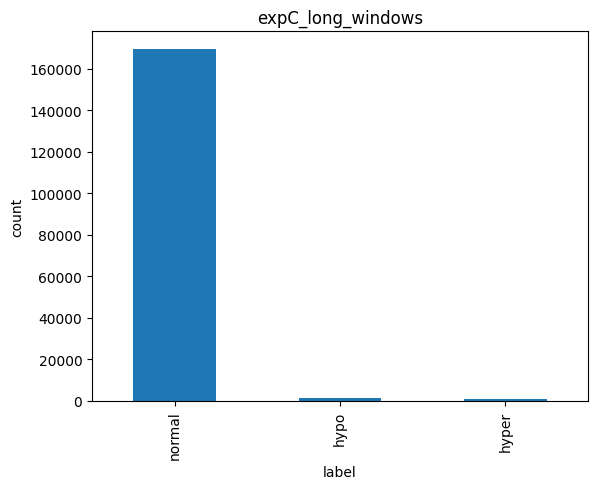

,patient_id,timestamp,time_idx,glucose,label,episode_id
0,P001,2020-01-01 00:00:00,0,113.256764,normal,None
1,P001,2020-01-01 00:05:00,1,131.161117,normal,None
2,P001,2020-01-01 00:10:00,2,133.062252,normal,None
3,P001,2020-01-01 00:15:00,3,104.146253,normal,None
4,P001,2020-01-01 00:20:00,4,110.634810,normal,None


In [4]:
def add_gaps(df, freq_min, gap_hours=12, n_gaps=3, seed=SEED):
    rng_local = np.random.default_rng(seed)
    gap_len = int(gap_hours * 60 / freq_min)
    out = []
    for patient_id, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp')
        mask = np.ones(len(g), dtype=bool)
        if len(g) > gap_len:
            for _ in range(n_gaps):
                start = rng_local.integers(0, len(g) - gap_len)
                mask[start:start + gap_len] = False
        out.append(g[mask])
    return pd.concat(out, ignore_index=True)

def sample_windows_by_days(df, freq_min, min_days, max_days, seed=SEED):
    rng_local = np.random.default_rng(seed)
    out = []
    for patient_id, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp')
        days = rng_local.integers(min_days, max_days + 1)
        window_len = int(days * 24 * 60 / freq_min)
        if len(g) <= window_len:
            out.append(g)
            continue
        start = rng_local.integers(0, len(g) - window_len)
        out.append(g.iloc[start:start + window_len])
    return pd.concat(out, ignore_index=True)

expC = {
    'expC_complete': base_df.copy(),
    'expC_gaps': add_gaps(base_df, FREQ_MIN, gap_hours=12, n_gaps=3),
    'expC_short_windows': sample_windows_by_days(base_df, FREQ_MIN, 1, 3),
    'expC_long_windows': sample_windows_by_days(base_df, FREQ_MIN, 14, 30),
}
for name, df in expC.items():
    plot_class_dist(df, name)

expC['expC_gaps'].head()

## Experimento D - Episode compression / sparsification

Este experimento simula perdida de resolucion y discontinuidad intra-episodio. Tecnica y clinicamente, esto ocurre por sensores de baja frecuencia, fallos de muestreo o filtrados agresivos. Se evalua el impacto de reducir frecuencia, eliminar puntos dentro de episodios y romper continuidad de hipoglucemia. La hipotesis es que estas distorsiones debilitan la deteccion de patrones previos a eventos criticos.

C:\Users\User\AppData\Local\Temp\ipykernel_8788\3813796448.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values('timestamp').iloc[::stride])


C:\Users\User\AppData\Local\Temp\ipykernel_8788\3813796448.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(drop_group)


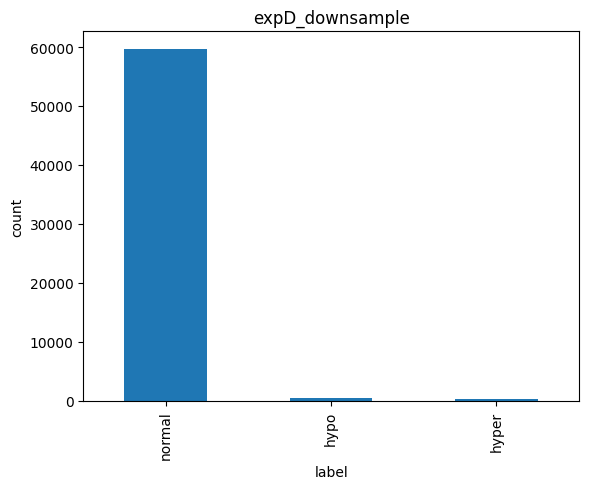

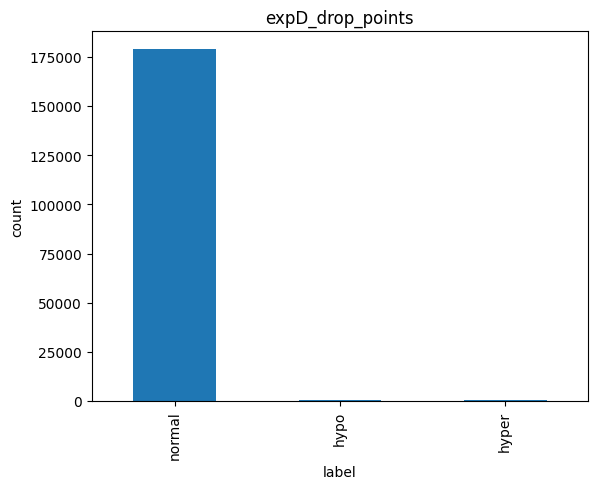

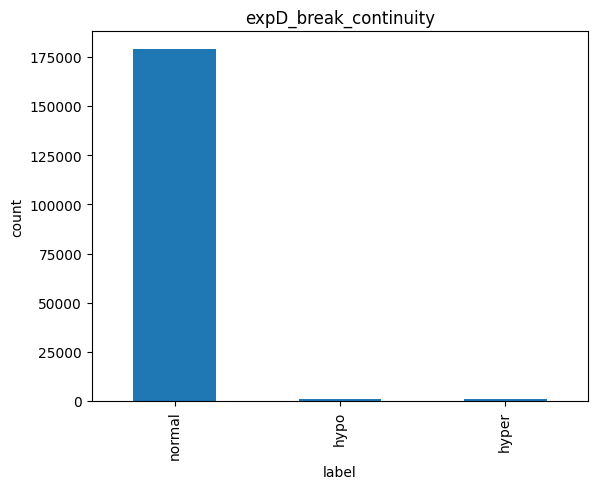

,patient_id,timestamp,time_idx,glucose,label,episode_id
0,P001,2020-01-01 00:00:00,0,113.256764,normal,None
1,P001,2020-01-01 00:15:00,3,104.146253,normal,None
2,P001,2020-01-01 00:30:00,6,120.494179,normal,None
3,P001,2020-01-01 00:45:00,9,132.450585,normal,None
4,P001,2020-01-01 01:00:00,12,134.929017,normal,None


In [5]:
def downsample_frequency(df, stride=3):
    return (
        df.groupby('patient_id', group_keys=False)
        .apply(lambda g: g.sort_values('timestamp').iloc[::stride])
        .reset_index(drop=True)
    )

def drop_within_episodes(df, drop_frac=0.5, seed=SEED):
    def drop_group(g):
        label = g['label'].iloc[0]
        if label in ('hypo', 'hyper'):
            return g.sample(frac=1 - drop_frac, random_state=seed)
        return g
    out = (
        df.groupby(['patient_id', 'episode_id'], dropna=False, group_keys=False)
        .apply(drop_group)
        .reset_index(drop=True)
    )
    return out

def break_episode_continuity(df, drop_prob=0.3, seed=SEED):
    rng_local = np.random.default_rng(seed)
    mask = np.ones(len(df), dtype=bool)
    episodic = df['label'].isin(['hypo', 'hyper'])
    rand = rng_local.random(len(df))
    mask[episodic & (rand < drop_prob)] = False
    return df[mask].reset_index(drop=True)

expD = {
    'expD_downsample': downsample_frequency(base_df, stride=3),
    'expD_drop_points': drop_within_episodes(base_df, drop_frac=0.5),
    'expD_break_continuity': break_episode_continuity(base_df, drop_prob=0.3),
}
for name, df in expD.items():
    plot_class_dist(df, name)

expD['expD_downsample'].head()

## Experimento E - Hybrid clinical realism scenario

Este escenario combina desbalanceo severo, fragmentacion temporal y heterogeneidad inter-paciente. La motivacion es aproximar un contexto clinico realista: pocos pacientes aportan grandes volumenes, la hipoglucemia es rara y hay gaps por uso irregular del CGM. La hipotesis es que este escenario es el mas desafiante y refleja el riesgo real de ignorar eventos hipoglucemicos. Se relaciona con el perfil de DIATREND (desbalanceo severo), T1DiabetesGranada (fragmentacion) y la heterogeneidad inter-paciente observada en ambos.

C:\Users\User\AppData\Local\Temp\ipykernel_8788\3813796448.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(drop_group)


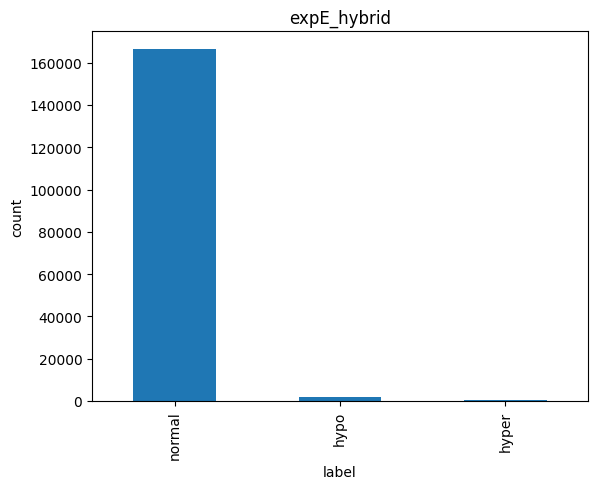

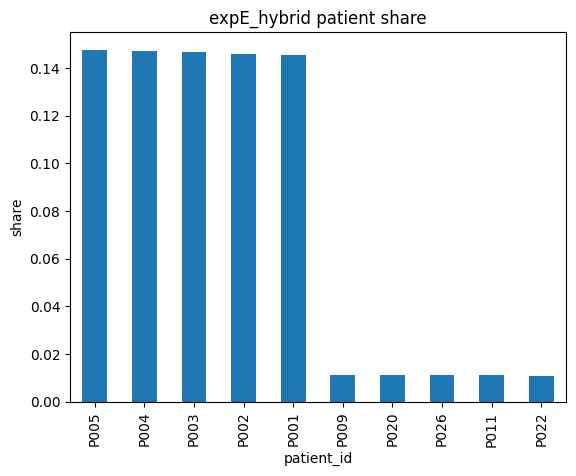

,patient_id,timestamp,time_idx,glucose,label,episode_id
0,P001,2020-01-11 15:15:00,3063,194.755947,hyper,P001_hyper_11
1,P001,2020-01-11 14:45:00,3057,190.938128,hyper,P001_hyper_11
2,P001,2020-01-11 15:05:00,3061,222.374696,hyper,P001_hyper_11
3,P001,2020-01-11 14:30:00,3054,186.273338,hyper,P001_hyper_11
4,P001,2020-01-11 15:10:00,3062,199.361687,hyper,P001_hyper_11


In [6]:
hybrid = patient_level_imbalance(base_df, 'dominant')
hybrid = add_gaps(hybrid, FREQ_MIN, gap_hours=8, n_gaps=4)
hybrid = scale_global_hypo_ratio(hybrid, 0.02)
hybrid = drop_within_episodes(hybrid, drop_frac=0.5)
plot_class_dist(hybrid, 'expE_hybrid')
plot_patient_share(hybrid, 'expE_hybrid patient share')

expE = {'expE_hybrid': hybrid}
expE['expE_hybrid'].head()

## Guardar escenarios

Guardamos todos los escenarios generados para el notebook de tecnicas de balanceo. Se usa CSV para evitar dependencias externas.

In [7]:
output_dir = Path('data/processed/experiments')
output_dir.mkdir(parents=True, exist_ok=True)

all_scenarios = {}
all_scenarios.update(expA)
all_scenarios.update(expB)
all_scenarios.update(expC)
all_scenarios.update(expD)
all_scenarios.update(expE)

for name, df in all_scenarios.items():
    path = output_dir / f'{name}.csv'
    df.to_csv(path, index=False)

sorted(all_scenarios.keys())

['expA_hypo_10',
 'expA_hypo_2',
 'expA_hypo_30',
 'expA_hypo_50',
 'expB_dominant',
 'expB_mixed',
 'expB_uniform',
 'expC_complete',
 'expC_gaps',
 'expC_long_windows',
 'expC_short_windows',
 'expD_break_continuity',
 'expD_downsample',
 'expD_drop_points',
 'expE_hybrid']

### Notas finales

Los escenarios generados aqui son controlados y reproducibles. El proximo notebook aplica tecnicas de balanceo para evaluar cuales preservan mejor la estructura temporal y los episodios de hipoglucemia, minimizando artefactos clinicamente implausibles.